In [2]:
import numpy as np
import scipy.sparse as sp
from numba import njit, prange


@njit
def compute_weights(mesh, indexes):
    weighs = np.zeros((*mesh.shape, 7), dtype=np.float64)

    n_j = mesh.shape[1]
    n_k = mesh.shape[2]
    for i in prange(indexes.shape[0]):
        ind = indexes[i]
        i = ind//(n_j*n_k)
        j = (ind % (n_j*n_k))//n_k
        k = (ind % (n_j*n_k)) % n_k
        
        w_central = 0
        w_id = 0

        for i_axis in range(3):
            for di in [-1, 1]:
                weighs[i, j, k, w_id] = mesh[i + di*(i_axis == 0),
                                             j + di*(i_axis == 1),
                                             k + di*(i_axis == 2)]
                w_central += mesh[i + di*(i_axis == 0),
                                  j + di*(i_axis == 1),
                                  k + di*(i_axis == 2)]
                w_id += 1

        weighs[i, j, k, 6] = - w_central

    return weighs


@njit
def compute_weights_2d(mesh, indexes):
    weighs = np.zeros((*mesh.shape, 5), dtype=np.float64)

    n_j = mesh.shape[1]
    for i in prange(indexes.shape[0]):
        ind = indexes[i]
        i = ind//n_j
        j = ind % n_j
        
        w_central = 0
        w_id = 0

        for i_axis in range(2):
            for di in [-1, 1]:
                weighs[i, j, w_id] = mesh[i + di*(i_axis == 0),
                                          j + di*(i_axis == 1)]
                w_central += mesh[i + di*(i_axis == 0),
                                  j + di*(i_axis == 1)]
                w_id += 1

        weighs[i, j, 4] = - w_central

    return weighs


def compute_sparse_weights(mesh, diffusion, indexes):

    ijk = np.array(np.unravel_index(indexes, mesh.shape))
    rows = np.empty((len(ijk), 2, len(indexes)), dtype=np.int64)
    cols = np.empty((len(ijk), 2, len(indexes)), dtype=np.int64)

    for i_axis in range(len(ijk)):
        for i, neighbor in enumerate([-1, 1]):
            neighbors = ijk.copy()
            neighbors[i_axis] += neighbor
            rows[i_axis, i, :] = indexes
            cols[i_axis, i, :] = np.ravel_multi_index(neighbors, mesh.shape)

    rows = rows.flatten()
    cols = cols.flatten()

    # data = 0.5 * mesh.flat[cols] * (diffusion.flat[cols] + diffusion.flat[rows])
    data = mesh.flat[cols]
    rows = rows[data > 0]
    cols = cols[data > 0]
    data = data[data > 0]

    c_indexes = np.zeros(mesh.size, dtype=np.int64)
    c_indexes[indexes] = np.arange(len(indexes))
    rows = c_indexes[rows]
    cols = c_indexes[cols]

    # print(rows)
    # print(cols)
    # print(data)

    size = len(indexes)
    shape = (size, size)
    A = sp.csr_matrix((data, (rows, cols)), shape=shape)
    row_sums = np.array(A.sum(axis=1)).ravel()
    D = sp.diags(-row_sums, offsets=0, format='csr')
    A_new = A + D
    return A_new.tocsr()

[ 0  3  6  9 12]
[0 1 2 0 1 3 0 2 3 1 2 3]
[0 0 0 1 1 1 2 2 2 3 3 3]
[0 1 2 0 1 3 0 2 3 1 2 3]
[-2.  1.  1.  1. -2.  1.  1. -2.  1.  1.  1. -2.]


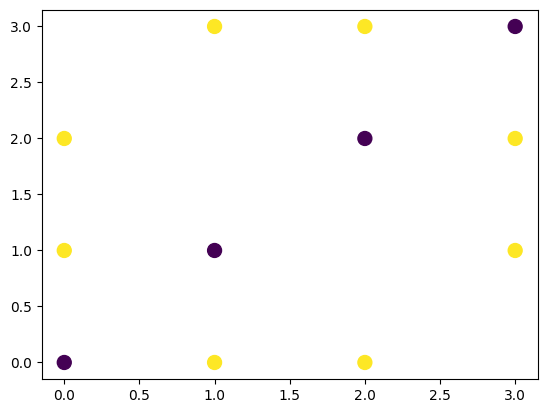

In [2]:
import matplotlib.pyplot as plt


mesh = np.ones((4, 4))
mesh[0, :] = 0
mesh[-1, :] = 0
mesh[:, 0] = 0
mesh[:, -1] = 0

indexes = np.flatnonzero(mesh)
diffusion = np.ones_like(mesh, dtype=np.float64)

a_scipy = compute_sparse_weights(mesh, diffusion, indexes)

print(a_scipy.indptr)
print(a_scipy.indices)

rows, cols = a_scipy.nonzero()

print(rows)
print(cols)
print(a_scipy.data)

plt.scatter(rows, cols, s=100, c=a_scipy.data, cmap='viridis')
plt.show()
# %timeit weighs = compute_weights(mesh, indexes)

indptr  = [0, 0, 0, 0, 0, 0, 3, 6, 6, 6, 9, 12]
indices = [5, 6, 9, 5, 6, 10, 5, 9, 10, 6, 9, 10]
data    = [-2., 1., 1., 1., -2., 1., 1., -2., 1., 1., 1., -2.]


In [ ]:
mesh = np.ones((200, 200, 20))
mesh[0, :, :] = 0
mesh[-1, :, :] = 0
mesh[:, 0, :] = 0
mesh[:, -1, :] = 0
mesh[:, :, 0] = 0
mesh[:, :, -1] = 0

indexes = np.flatnonzero(mesh)
diffusion = np.ones_like(mesh, dtype=np.float64)

%timeit a_scipy = compute_sparse_weights(mesh, diffusion, indexes)
%timeit weighs = compute_weights(mesh, indexes)

185 ms ± 14.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
8.76 ms ± 284 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [3]:
from numba import prange, njit
from threadpoolctl import threadpool_limits


@njit(parallel=True, fastmath=True)
def diffusion_numba(u_new, u, weighs, indexes, rhs):
    n_j = u.shape[1]
    n_k = u.shape[2]
    for i in prange(indexes.shape[0]):
        ind = indexes[i]
        i = ind//(n_j*n_k)
        j = (ind % (n_j*n_k))//n_k
        k = (ind % (n_j*n_k)) % n_k
        u_new[i, j, k] += (weighs[i, j, k, 0] * u[i - 1, j, k] + 
                           weighs[i, j, k, 1] * u[i + 1, j, k] +
                           weighs[i, j, k, 2] * u[i, j - 1, k] +
                           weighs[i, j, k, 3] * u[i, j + 1, k] +
                           weighs[i, j, k, 4] * u[i, j, k - 1] +
                           weighs[i, j, k, 5] * u[i, j, k + 1] + 
                           weighs[i, j, k, 6] * u[i, j, k]) + rhs[i, j, k]

    return u_new


@njit(parallel=True, fastmath=True)
def diffusion_numba_2d(u_new, u, weighs, indexes, rhs):
    n_j = u.shape[1]
    for i in prange(indexes.shape[0]):
        ind = indexes[i]
        i = ind//n_j
        j = ind % n_j
        u_new[i, j] += (weighs[i, j, 0] * u[i - 1, j] + 
                        weighs[i, j, 1] * u[i + 1, j] +
                        weighs[i, j, 2] * u[i, j - 1] +
                        weighs[i, j, 3] * u[i, j + 1] + 
                        weighs[i, j, 4] * u[i, j]) + rhs[i, j]

    return u_new


@njit(parallel=True, fastmath=True)
def diffusion_sparse_numba(indptr, indices, data, u_new, u, rhs, indexes):
    n_rows = indptr.size - 1
    
    for i in prange(n_rows):
        start = indptr[i]
        end = indptr[i + 1]
        if start == end:
            continue
        acc = 0.0
        for j in range(start, end):
            jj = indices[j]
            jj = indexes[jj]
            acc += data[j] * u.flat[jj]
        
        ii = indexes[i]
        u_new.flat[ii] = acc + rhs.flat[ii]
    
    return u_new


@threadpool_limits.wrap(limits=1, user_api="blas")
def diffusion_sparse_scipy(A, u):
    return A @ u


In [6]:
from pathlib import Path
import numpy as np
import scipy.sparse as sp


path = Path("/Users/arstanbek/Projects/fibrosis/Finitewave/examples/data/mesh.npy")

# mesh = np.load(path)

mesh = np.ones((400, 400))
# mesh[np.random.random(mesh.shape) < -0.5] = 0
mesh[0, :] = 0
mesh[-1, :] = 0
mesh[:, 0] = 0
mesh[:, -1] = 0

indexes = np.flatnonzero(mesh)

print(indexes.shape)

diffusion = np.ones_like(mesh).astype(np.float64)
u = np.random.random(mesh.shape).astype(np.float64)
rhs = np.random.random(mesh.shape).astype(np.float64)
u_new = np.zeros_like(u)

theta = 0
diffusion_asymmetric = np.zeros((*mesh.shape, mesh.ndim, mesh.ndim))
diffusion_asymmetric[:, :, 0, 0] = 1
diffusion_asymmetric[:, :, 0, 1] = 0
diffusion_asymmetric[:, :, 1, 0] = 0
diffusion_asymmetric[:, :, 1, 1] = 1
# diffusion[:, :, 1, 2] = 0
# diffusion[:, :, 2, 0] = 0
# diffusion[:, :, 2, 1] = 0
# diffusion[:, :, 2, 2] = 1

a_scipy = compute_sparse_weights(mesh, diffusion, indexes)
a_asymmetric = compute_weights_asymmetric(mesh, diffusion_asymmetric, indexes)
weighs = compute_weights_2d(mesh, indexes)

x = diffusion_numba_2d(u_new, u, weighs, indexes, rhs)
x = diffusion_sparse_numba(a_scipy.indptr, a_scipy.indices, a_scipy.data,
                           u_new, u, rhs, indexes)

%timeit x = diffusion_numba_2d(u_new, u, weighs, indexes, rhs)
%timeit x = diffusion_sparse_numba(a_scipy.indptr, a_scipy.indices, a_scipy.data, u_new, u, rhs, indexes)
%timeit x = diffusion_sparse_numba(a_asymmetric.indptr, a_asymmetric.indices, a_asymmetric.data, u_new, u, rhs, indexes)

(158404,)
279 µs ± 1.11 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
254 µs ± 766 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
253 µs ± 692 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [69]:
u_new.dtype, u.dtype, rhs.dtype

(dtype('float64'), dtype('float64'), dtype('float64'))

Running AlievPanfilov on grid [400, 400]: 100%|██████████| 1000/1000 [00:00<00:00, 1374.96it/s]


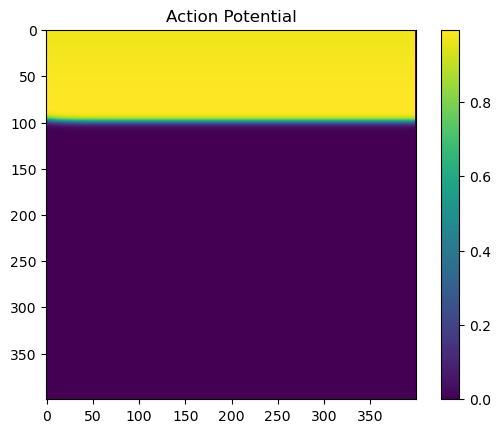

In [97]:

import numpy as np
import matplotlib.pyplot as plt

import finitewave.gridywave as fw

# create a tissue:
n, m = mesh.shape

# set up stimulation parameters:
stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimVoltageGridCoord(0, 1, 0, 5, 0, m))

action_pot_tracker = fw.ActionPotentialGridTracker()
# to specify the mesh node under the measuring - use the cell_ind field:
# eather list or list of lists can be used
action_pot_tracker.cell_ind = [[50, 3]]
action_pot_tracker.step = 1

tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(action_pot_tracker)

simulation = fw.CardiacGridSimulation()
simulation.dt = 0.01
simulation.dr = 0.25
simulation.t_max = 10
# add the tissue and the stim parameters to the model object:
simulation.cardiac_tissue = fw.CardiacTissueGrid([n, m])
simulation.cardiac_model = fw.AlievPanfilov()
simulation.stim_sequence = stim_sequence

# run the model:
simulation.run()

# # plot the action potential
plt.figure()
plt.imshow(simulation.cardiac_model.u)
plt.colorbar()
plt.title('Action Potential')
plt.show()


In [100]:
A, M = simulation.diffusion_model.matrices
u_new_m = simulation.diffusion_model.u_new.copy()
u_m = simulation.cardiac_model.u.copy()
rhs_m = simulation.cardiac_model.rhs.copy()
indexes = simulation.cardiac_model.myo_indexes.copy()

print(indexes.shape)

# print(A.indptr)
# print(A.indices)
# print(A.data)

# print(u_new)
# print(u)
# print(rhs)
# print(indexes)

x = diffusion_sparse_numba(a_scipy.indptr, a_scipy.indices, a_scipy.data, u_new, u, rhs, indexes)
%timeit x = diffusion_sparse_numba(A.indptr, A.indices, A.data, u_new, u, rhs, indexes)
%timeit x = diffusion_sparse_numba(A.indptr, A.indices, A.data, u_new_m, u_m, rhs_m, indexes)

(158404,)
283 µs ± 28.2 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
269 µs ± 14.9 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [105]:
A, M = simulation.diffusion_model.matrices
u_new_m = simulation.diffusion_model.u_new
u_m = simulation.cardiac_model.u
rhs_m = simulation.cardiac_model.rhs
indexes = simulation.cardiac_model.myo_indexes

u_new = simulation.diffusion_model.u_new.copy()
u = simulation.cardiac_model.u.copy()
rhs = simulation.cardiac_model.rhs.copy()
indexes = simulation.cardiac_model.myo_indexes.copy()

%timeit x = diffusion_sparse_numba(A.indptr, A.indices, A.data, u_new_m, u_m, rhs_m, indexes)
%timeit x = diffusion_sparse_numba(A.indptr, A.indices, A.data, u_new, u, rhs, indexes)

426 µs ± 15.4 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
258 µs ± 4.61 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


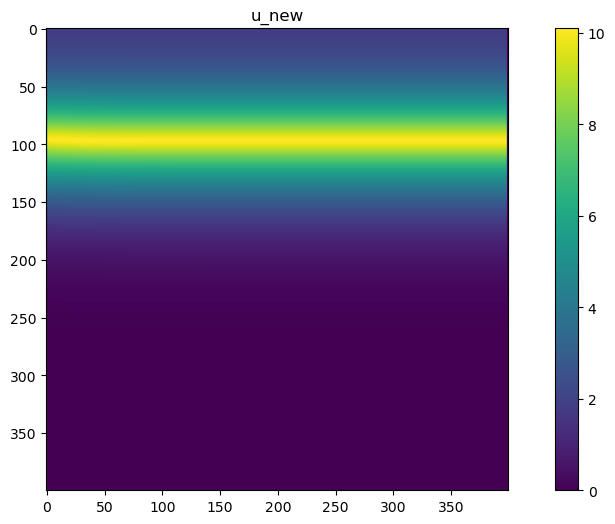

In [104]:
u_new_m = simulation.diffusion_model.u_new
u_m = simulation.cardiac_model.u.copy
rhs_m = simulation.cardiac_model.rhs.copy
indexes = simulation.cardiac_model.myo_indexes

plt.figure(figsize=(12, 6))
plt.imshow(simulation.cardiac_model.u, cmap='viridis')
plt.colorbar()
plt.title('u_new')
plt.show()

In [ ]:
from scipy import sparse as sp
import matplotlib.pyplot as plt
import numpy as np

theta = np.pi / 4
m = np.ones((3, 3))


indexes = np.flatnonzero(m)
diffusion = np.zeros((*m.shape, m.ndim, m.ndim))
diffusion[:, :, 0, 0] = np.cos(theta)
diffusion[:, :, 0, 1] = np.sin(theta)
diffusion[:, :, 1, 0] = np.sin(theta)
diffusion[:, :, 1, 1] = np.cos(theta)
# diffusion[:, :, 1, 2] = 0
# diffusion[:, :, 2, 0] = 0
# diffusion[:, :, 2, 1] = 0
# diffusion[:, :, 2, 2] = 1

rows, cols, weights = compute_weights(m, diffusion, indexes)


size = m.size
shape = (size, size)
K = sp.csr_matrix((weights, (rows, cols)), shape=shape)
M = sp.diags(np.ones_like(indexes), offsets=0, format='csr')



True

In [4]:
import numpy as np


# def minor_component(a, b, c, d):
#     s = a + b + c + d
#     s = np.where(s < 3, 0, 1 / s)
#     return s

def minor_component(m, m0, m1, m2, m3, m4):
    """
    Calculates the flow weights from m2 to m3 using an asymmetric stencil.

    .. code-block:: text
        m3 ----- m4
        |        |
        |        |
        |        |
        m0 - d - m
        |        |
        |        |
        |        |
        m1 ----- m2
    """
    m_upper = m3 + m4 + m + m0
    m_lower = m1 + m2 + m + m0

    mask = ((m == 0) | (m3 == 0) | (m_upper < 3) | (m_lower < 3))

    w = np.where(mask, 0, m / m_upper - m / m_lower)
    w0 = np.where(mask, 0, m0 / m_upper - m0 / m_lower)
    w1 = np.where(mask, 0, - m1 / m_lower)
    w2 = np.where(mask, 0, - m2 / m_lower)
    w3 = np.where(mask, 0, m3 / m_upper)
    w4 = np.where(mask, 0, m4 / m_upper)

    return w, w0, w1, w2, w3, w4

def flow_weights(d_major, d_minor, m, m0, m1, m2, m3, m4):
    """
    Calculates the flow weights from m2 to m3 using an asymmetric stencil.

    .. code-block:: text
        m3 ----- m4
        |        |
        |        |
        |        |
        m0 - d - m
        |        |
        |        |
        |        |
        m1 ----- m2
    """

    w, w0, w1, w2, w3, w4 = minor_component(m, m0, m1, m2, m3, m4)

    w  = - d_major * m0 + d_minor * w
    w0 = d_major * m0 + d_minor * w0
    w1 *= d_minor
    w2 *= d_minor

    w3 *= d_minor
    w4 *= d_minor

    return w, w0, w1, w2, w3, w4


def check_boundary(ijk, mesh, i_axis):
    mask = ((ijk[i_axis] >= 0) & (ijk[i_axis] < mesh.shape[i_axis]))
    mask[mask] = mesh[tuple(ijk[:, mask])] > 0
    return mask.astype(mesh.dtype)


def majors(indexes, mesh, major_axis, major_neighbor):
    ijk_center = np.array(np.unravel_index(indexes, mesh.shape))
    m_center = mesh[tuple(ijk_center)]

    ijk_major = ijk_center.copy()
    ijk_major[major_axis] += major_neighbor
    m_major = check_boundary(ijk_major, mesh, major_axis)

    major_mask = m_major > 0
    ijk_center = ijk_center[:, major_mask]
    m_center = m_center[major_mask]
    ijk_major = ijk_major[:, major_mask]
    m_major = m_major[major_mask]
    return ijk_center, ijk_major, m_center, m_major, major_mask


def minors(ijk, mesh, minor_axis, minor_neighbor):
    ijk_minor = ijk.copy()
    ijk_minor[minor_axis] += minor_neighbor
    m_minor = check_boundary(ijk_minor, mesh, minor_axis)
    return ijk_minor, m_minor


def compute_flow_weights(d_major, d_minor, major_axis, minor_axis,
                         major_neighbor, mesh, indexes):
    """
    Calculates the flow from major to center.

    .. code-block:: text
        upper_major ----- upper_center
            |                   |
            |                   |
            |                   |
          major ------ d ---- center
            |                   |
            |                   |
            |                   |
        lower_major ----- lower_center
    """
    minor_lower = major_neighbor
    minor_upper = - major_neighbor

    res = majors(indexes, mesh, major_axis, major_neighbor)
    ijk_center, ijk_major, m_center, m_major, major_mask = res

    ijk_lower_major, m_lower_major = minors(ijk_major, mesh, minor_axis, minor_lower)
    ijk_lower_center, m_lower_center = minors(ijk_center, mesh, minor_axis, minor_lower)
    ijk_upper_major, m_upper_major = minors(ijk_major, mesh, minor_axis, minor_upper)
    ijk_upper_center, m_upper_center = minors(ijk_center, mesh, minor_axis, minor_upper)

    multi_ijk = [ijk_center, ijk_major, ijk_lower_major, ijk_lower_center,
                 ijk_upper_major, ijk_upper_center]
    
    d_major = 0.5 * (d_major + np.roll(d_major, -major_neighbor))[major_mask]
    d_minor = 0.5 * (d_minor + np.roll(d_minor, -major_neighbor))[major_mask]

    weights = flow_weights(d_major, d_minor, m_center, m_major, m_lower_major,
                           m_lower_center, m_upper_major, m_upper_center)
    
    rows = [np.ravel_multi_index(ijk_center[:, w != 0], mesh.shape)
            for w in weights]
    cols = [np.ravel_multi_index(ijk[:, w != 0], mesh.shape)
            for ijk, w in zip(multi_ijk, weights)]
    data = [w[w != 0] for w in weights]

    return rows, cols, data


def compute_weights_asymmetric(mesh, diffusion, indexes):
    rows, cols, weights = [], [], []
    ijk = np.array(np.unravel_index(indexes, mesh.shape))
    for i in range(mesh.ndim):
        axis = np.roll(np.arange(mesh.ndim), i)
        major_axis = axis[0]
        minor_axes = axis[1:]
        for minor_axis in minor_axes:
            d_major = diffusion[*ijk, major_axis, major_axis]
            d_minor = diffusion[*ijk, major_axis, minor_axis]
            for major_neighbor in [-1, 1]:
                res = compute_flow_weights(d_major, d_minor,
                                                        major_axis, minor_axis,
                                                        major_neighbor, mesh,
                                                        indexes)
                rows += res[0]
                cols += res[1]
                weights += res[2]
                # print(rows[-1], cols[-1], weights[-1])
    rows = np.concatenate(rows)
    cols = np.concatenate(cols)
    weights = np.concatenate(weights)
    size = mesh.size
    shape = (size, size)
    K = sp.csr_matrix((weights, (rows, cols)), shape=shape)
    return K

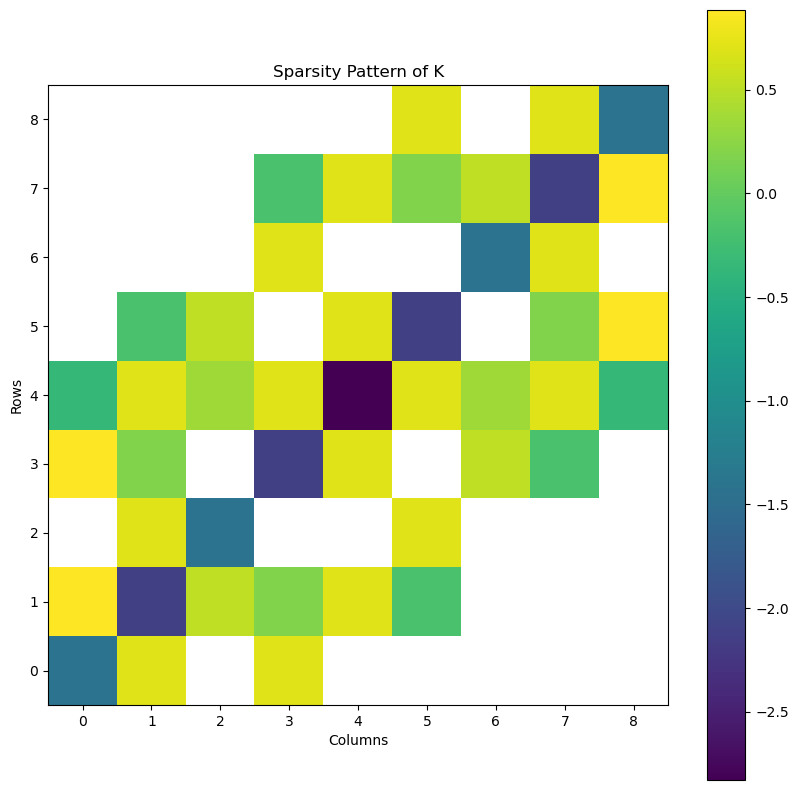

In [ ]:
from scipy import sparse as sp
import matplotlib.pyplot as plt
import numpy as np

theta = np.pi / 4
m = np.ones((3, 3))


indexes = np.flatnonzero(m)
diffusion = np.zeros((*m.shape, m.ndim, m.ndim))
diffusion[:, :, 0, 0] = np.cos(theta)
diffusion[:, :, 0, 1] = np.sin(theta)
diffusion[:, :, 1, 0] = np.sin(theta)
diffusion[:, :, 1, 1] = np.cos(theta)
# diffusion[:, :, 1, 2] = 0
# diffusion[:, :, 2, 0] = 0
# diffusion[:, :, 2, 1] = 0
# diffusion[:, :, 2, 2] = 1

rows, cols, weights = compute_weights(m, diffusion, indexes)


size = m.size
shape = (size, size)
K = sp.csr_matrix((weights, (rows, cols)), shape=shape)
M = sp.diags(np.ones_like(indexes), offsets=0, format='csr')

K_masked = np.ma.where(K.toarray() == 0, np.nan, K.toarray())
# K_masked = K.toarray()

%matplotlib inline
plt.figure(figsize=(10, 10))
plt.imshow(K_masked, origin="lower", cmap='viridis')
plt.title("Sparsity Pattern of K")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.colorbar()
plt.show()